In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import optuna

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG19
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, LearningRateScheduler

from optuna.integration import TFKerasPruningCallback

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import sklearn.metrics as metrics

annealer = LearningRateScheduler(lambda epoch: 1e-3 * (0.95 ** epoch), verbose=0)

In [3]:
import os
import pandas as pd

base_dir = "AugmentedAlzheimerDataset"

MildDemented_dir = os.path.join(base_dir, "MildDemented")
ModerateDemented_dir = os.path.join(base_dir, "ModerateDemented")
NonDemented_dir = os.path.join(base_dir, "NonDemented")
VeryMildDemented_dir = os.path.join(base_dir, "VeryMildDemented")

filepaths = []
labels = []
dict_list = [MildDemented_dir, ModerateDemented_dir, NonDemented_dir, VeryMildDemented_dir]
class_labels = ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very MildDemented']

for i, j in enumerate(dict_list):
    flist = os.listdir(j)
    for f in flist:
        fpath = os.path.join(j, f)
        filepaths.append(fpath)
        labels.append(class_labels[i])

Fseries = pd.Series(filepaths, name="filepaths")
Lseries = pd.Series(labels, name="labels")
Alzheimer_data = pd.concat([Fseries, Lseries], axis=1)
Alzheimer_df = pd.DataFrame(Alzheimer_data)
print(Alzheimer_df.head())
print(Alzheimer_df["labels"].value_counts())

                                           filepaths         labels
0  AugmentedAlzheimerDataset\MildDemented\002cb9c...  Mild Demented
1  AugmentedAlzheimerDataset\MildDemented\0033c40...  Mild Demented
2  AugmentedAlzheimerDataset\MildDemented\00372fb...  Mild Demented
3  AugmentedAlzheimerDataset\MildDemented\00387cf...  Mild Demented
4  AugmentedAlzheimerDataset\MildDemented\0045bd9...  Mild Demented
labels
Non Demented         9600
Very MildDemented    8960
Mild Demented        8954
Moderate Demented    6464
Name: count, dtype: int64


In [4]:
Alzheimer_df.shape

(33978, 2)

In [5]:
train_dummy, test_images = train_test_split(Alzheimer_df, test_size=0.2, random_state=42)
train_set, val_set = train_test_split(train_dummy, test_size=0.2, random_state=42)

In [6]:
print(train_set.shape)
print(test_images.shape)
print(val_set.shape)
print(train_dummy.shape)

(21745, 2)
(6796, 2)
(5437, 2)
(27182, 2)


In [7]:
image_gen = ImageDataGenerator(preprocessing_function= tf.keras.applications.mobilenet_v2.preprocess_input)
train = image_gen.flow_from_dataframe(dataframe= train_set,x_col="filepaths",y_col="labels",
                                      target_size=(244,244),
                                      color_mode='rgb',
                                      class_mode="categorical", #used for Sequential Model
                                      batch_size=32,
                                      shuffle=False            #do not shuffle data
                                     )
test = image_gen.flow_from_dataframe(dataframe= test_images,x_col="filepaths", y_col="labels",
                                     target_size=(244,244),
                                     color_mode='rgb',
                                     class_mode="categorical",
                                     batch_size=32,
                                     shuffle= False
                                    )
val = image_gen.flow_from_dataframe(dataframe= val_set,x_col="filepaths", y_col="labels",
                                    target_size=(244,244),
                                    color_mode= 'rgb',
                                    class_mode="categorical",
                                    batch_size=32,
                                    shuffle=False
                                   )

Found 21745 validated image filenames belonging to 4 classes.
Found 6796 validated image filenames belonging to 4 classes.
Found 5437 validated image filenames belonging to 4 classes.


In [8]:
classes=list(train.class_indices.keys())
print (classes)

['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very MildDemented']


In [9]:
def show_knee_images(image_gen):
    test_dict = test.class_indices
    classes = list(test_dict.keys())
    images, labels=next(image_gen) # get a sample batch from the generator
    plt.figure(figsize=(20,20))
    length = len(labels)
    if length<25:
        r=length
    else:
        r=25
    for i in range(r):
        plt.subplot(5,5,i+1)
        image=(images[i]+1)/2 #scale images between 0 and 1
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color="green",fontsize=16)
        plt.axis('off')
    plt.show()

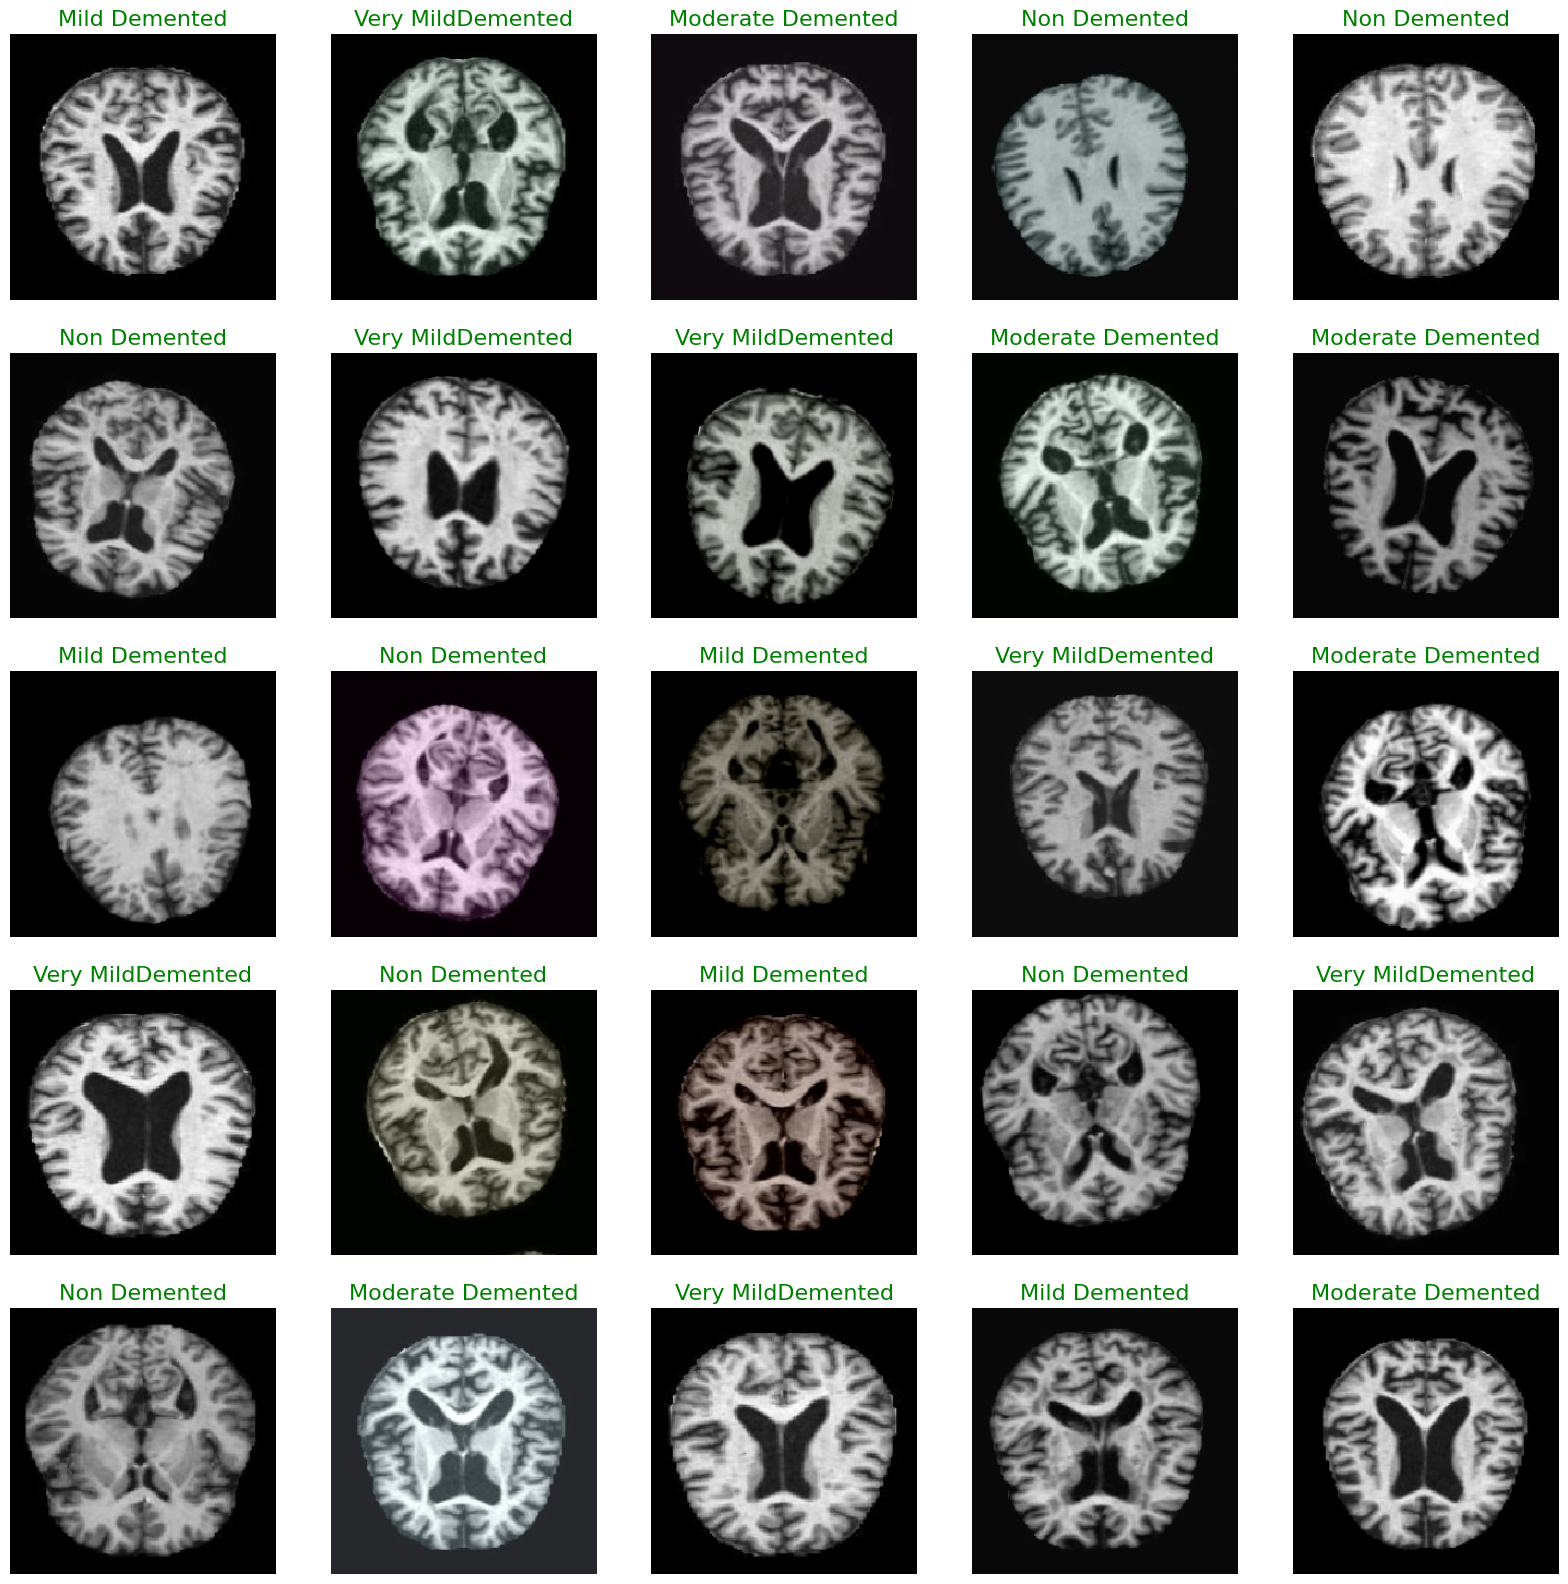

In [10]:
show_knee_images(train)

In [11]:
def objective(trial):
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.3, 0.7)
    dense_units = trial.suggest_categorical("dense_units", [512, 1024, 2048])
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])

    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(filters=128, kernel_size=(8, 8), strides=(3, 3), activation='relu', input_shape=(244, 244, 3)),
        tf.keras.layers.BatchNormalization(),
        
        tf.keras.layers.Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPool2D(pool_size=(3, 3)),
        
        tf.keras.layers.Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(filters=256, kernel_size=(1, 1), strides=(1, 1), activation='relu', padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(filters=256, kernel_size=(1, 1), strides=(1, 1), activation='relu', padding="same"),
        tf.keras.layers.BatchNormalization(),
        
        tf.keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
        
        tf.keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
        tf.keras.layers.BatchNormalization(),
        
        tf.keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
        tf.keras.layers.BatchNormalization(),
        
        tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
        
        tf.keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
        tf.keras.layers.BatchNormalization(),
        
        tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
        
        tf.keras.layers.Flatten(),
        
        tf.keras.layers.Dense(dense_units, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(dense_units, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),
        
        tf.keras.layers.Dense(4, activation='softmax')
    ])

    if optimizer_name == "Adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr)

    model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )

    history = model.fit(
        train, 
        validation_data=val, 
        epochs=5,
        callbacks=[TFKerasPruningCallback(trial, 'val_accuracy')],
        verbose=0 
    )

    return history.history['val_accuracy'][-1]

In [12]:
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())

print("Iniciando la búsqueda de hiperparámetros...")
study.optimize(objective, n_trials=10)

print("Los mejores hiperparámetros encontrados son:")
print(study.best_trial.params)
print(f"Mejor precisión de validación lograda: {study.best_trial.value:.4f}")

[I 2026-07-06 00:06:57,017] A new study created in memory with name: no-name-58c54460-7e93-44e8-9012-93c9404b9b4f


Iniciando la búsqueda de hiperparámetros...


[I 2026-07-06 00:14:12,842] Trial 0 finished with value: 0.7548280358314514 and parameters: {'learning_rate': 0.0019047585540909297, 'dropout_rate': 0.43811409348578323, 'dense_units': 2048, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.7548280358314514.
[I 2026-07-06 00:21:01,636] Trial 1 finished with value: 0.6413463354110718 and parameters: {'learning_rate': 0.001145581485168548, 'dropout_rate': 0.6919289424563715, 'dense_units': 512, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.7548280358314514.
[I 2026-07-06 00:28:05,659] Trial 2 finished with value: 0.8535957336425781 and parameters: {'learning_rate': 0.0001596410492995543, 'dropout_rate': 0.30177789959399376, 'dense_units': 2048, 'optimizer': 'Adam'}. Best is trial 2 with value: 0.8535957336425781.
[I 2026-07-06 00:35:09,592] Trial 3 finished with value: 0.7364355325698853 and parameters: {'learning_rate': 0.005222004746203529, 'dropout_rate': 0.5298317527443203, 'dense_units': 1024, 'optimizer': 'SGD'}. Best is tria

Los mejores hiperparámetros encontrados son:
{'learning_rate': 0.0001596410492995543, 'dropout_rate': 0.30177789959399376, 'dense_units': 2048, 'optimizer': 'Adam'}
Mejor precisión de validación lograda: 0.8536


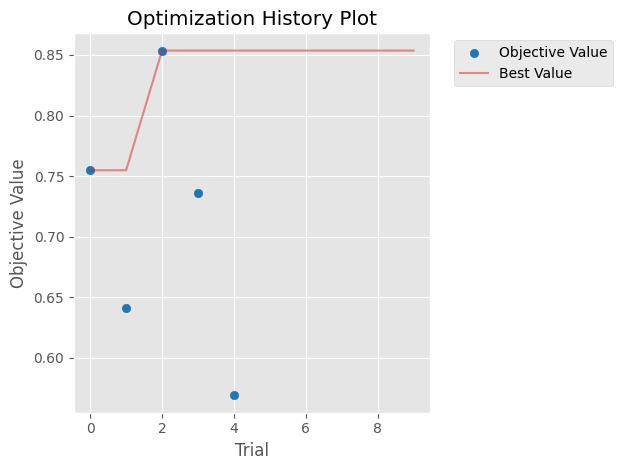

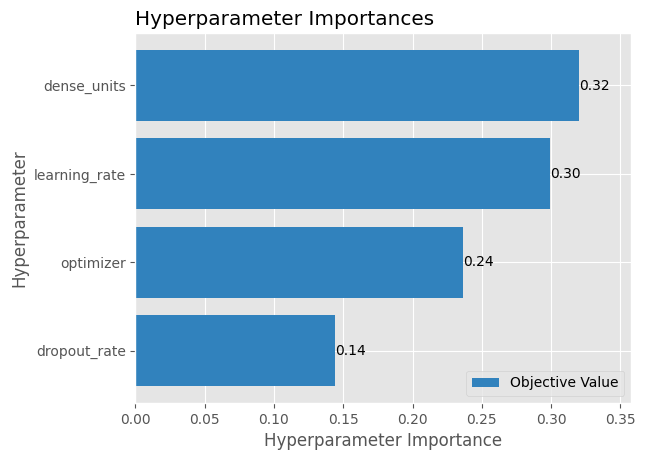

In [13]:
import matplotlib.pyplot as plt
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

# Generar gráfico de historial
plot_optimization_history(study)
plt.show()

# Generar gráfico de importancia
plot_param_importances(study)
plt.show()

In [14]:
best_lr = study.best_params['learning_rate']
best_dropout = study.best_params['dropout_rate']
best_dense = study.best_params['dense_units']
best_opt = study.best_params['optimizer']

In [15]:
final_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(128, (8, 8), strides=(3, 3), activation='relu', input_shape=(244, 244, 3)),
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Conv2D(256, (5, 5), strides=(1, 1), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(pool_size=(3, 3)),
    
    tf.keras.layers.Conv2D(256, (3, 3), strides=(1, 1), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(256, (1, 1), strides=(1, 1), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(256, (1, 1), strides=(1, 1), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    
    tf.keras.layers.Flatten(),
    
    # Inyectamos los hiperparámetros optimizados
    tf.keras.layers.Dense(best_dense, activation='relu'),
    tf.keras.layers.Dropout(best_dropout),
    tf.keras.layers.Dense(best_dense, activation='relu'),
    tf.keras.layers.Dropout(best_dropout),
    tf.keras.layers.Dense(4, activation='softmax')
])

In [16]:
optimizer = tf.keras.optimizers.Adam(learning_rate=best_lr) if best_opt == "Adam" else tf.keras.optimizers.SGD(learning_rate=best_lr)

final_model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

In [17]:
history_final = final_model.fit(
    train, 
    epochs=22, 
    validation_data=val, 
    callbacks=[annealer]
)

Epoch 1/22
680/680 [==============================] - 96s 140ms/step - loss: 1.2154 - accuracy: 0.4847 - val_loss: 0.9669 - val_accuracy: 0.5060 - lr: 0.0010
Epoch 2/22
680/680 [==============================] - 97s 143ms/step - loss: 0.8521 - accuracy: 0.5871 - val_loss: 0.8391 - val_accuracy: 0.6180 - lr: 9.5000e-04
Epoch 3/22
680/680 [==============================] - 98s 144ms/step - loss: 0.7698 - accuracy: 0.6179 - val_loss: 0.8987 - val_accuracy: 0.5830 - lr: 9.0250e-04
Epoch 4/22
680/680 [==============================] - 95s 140ms/step - loss: 0.6948 - accuracy: 0.6651 - val_loss: 0.6728 - val_accuracy: 0.6978 - lr: 8.5737e-04
Epoch 5/22
680/680 [==============================] - 97s 142ms/step - loss: 0.5809 - accuracy: 0.7294 - val_loss: 0.6740 - val_accuracy: 0.6802 - lr: 8.1451e-04
Epoch 6/22
680/680 [==============================] - 91s 134ms/step - loss: 0.4950 - accuracy: 0.7743 - val_loss: 0.4611 - val_accuracy: 0.7953 - lr: 7.7378e-04
Epoch 7/22
680/680 [============

In [18]:
final_model.evaluate(test, verbose=1)

213/213 [==============================] - 11s 50ms/step - loss: 0.1233 - accuracy: 0.9653


[0.12326651811599731, 0.9652736783027649]

In [19]:
final_model.save("Alzheimer_Model_Optimized.h5")

In [20]:
pred = final_model.predict(test)
pred = np.argmax(pred, axis=1)

labels = (train.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred2 = [labels[k] for k in pred]

213/213 [==============================] - 7s 33ms/step


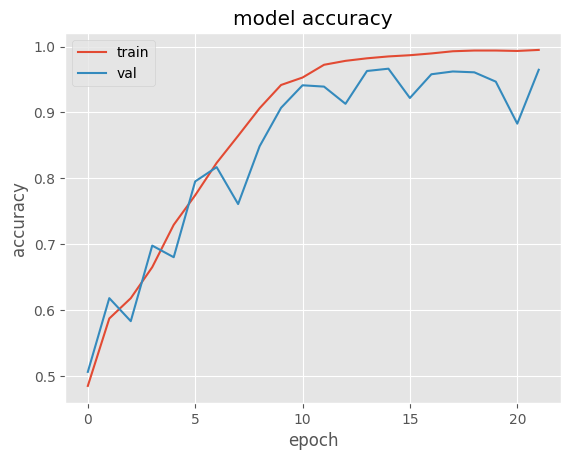

In [21]:
plt.plot(history_final.history['accuracy'])
plt.plot(history_final.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

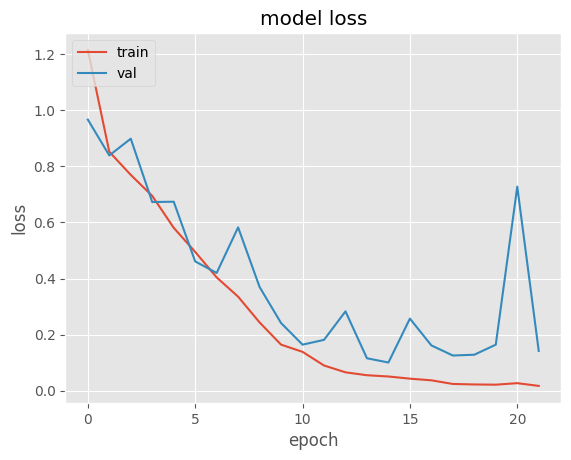

In [22]:
plt.plot(history_final.history['loss'])
plt.plot(history_final.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [23]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_test = test_images.labels # set y_test to the expected output
print(classification_report(y_test, pred2))
print("Accuracy of the Model:","{:.1f}%".format(accuracy_score(y_test, pred2)*100))

                   precision    recall  f1-score   support

    Mild Demented       0.99      0.98      0.98      1799
Moderate Demented       1.00      1.00      1.00      1321
     Non Demented       0.99      0.91      0.95      1883
Very MildDemented       0.90      0.99      0.94      1793

         accuracy                           0.97      6796
        macro avg       0.97      0.97      0.97      6796
     weighted avg       0.97      0.97      0.97      6796

Accuracy of the Model: 96.5%


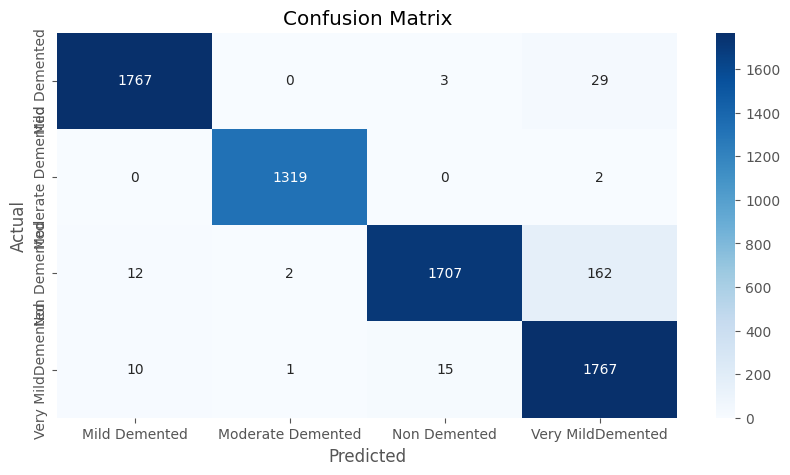

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Define the class labels
class_labels = ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very MildDemented']

# Calculate the confusion matrix
cm = confusion_matrix(y_test, pred2)

# Create a figure and plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues')

# Set tick labels and axis labels
plt.xticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels)
plt.yticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Set the title
plt.title("Confusion Matrix")

# Show the plot
plt.show()